# Telecom Customer Churn Prediction & Retention Strategy

This notebook completes the full machine-learning workflow: data cleaning, EDA, feature engineering, model comparison, Random Forest tuning, and business recommendations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
data_path = project_root / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")

## 1. Load and inspect the data

In [2]:
raw_df = pd.read_csv(data_path)
print(f"Dataset shape: {raw_df.shape}")
display(raw_df.head())
display(raw_df.dtypes.to_frame("data_type"))
display(raw_df["Churn"].value_counts(normalize=True).mul(100).rename("percentage"))

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,data_type
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


Churn
No     73.463013
Yes    26.536987
Name: percentage, dtype: float64

## 2. Clean the data and engineer features

In [3]:
df = raw_df.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
blank_total_charges = df["TotalCharges"].isna().sum()
duplicate_rows = df.duplicated().sum()

df = df.dropna(subset=["TotalCharges"]).drop_duplicates()
df = df.replace({"No internet service": "No", "No phone service": "No"})

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, np.inf],
    labels=["0-12", "13-24", "25-48", "49+"],
)
df["average_monthly_spend"] = df["TotalCharges"] / df["tenure"].replace(0, np.nan)
df["average_monthly_spend"] = df["average_monthly_spend"].fillna(df["MonthlyCharges"])

add_on_columns = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
]
df["services_count"] = df[add_on_columns].eq("Yes").sum(axis=1)

print(f"Blank TotalCharges rows removed: {blank_total_charges}")
print(f"Exact duplicate rows removed: {duplicate_rows}")
print(f"Cleaned dataset shape: {df.shape}")
display(df.head())

Blank TotalCharges rows removed: 11
Exact duplicate rows removed: 0
Cleaned dataset shape: (7032, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,average_monthly_spend,services_count
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12,29.850000,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,25-48,55.573529,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12,54.075000,2
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48,40.905556,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12,75.825000,0


## 3. Exploratory data analysis

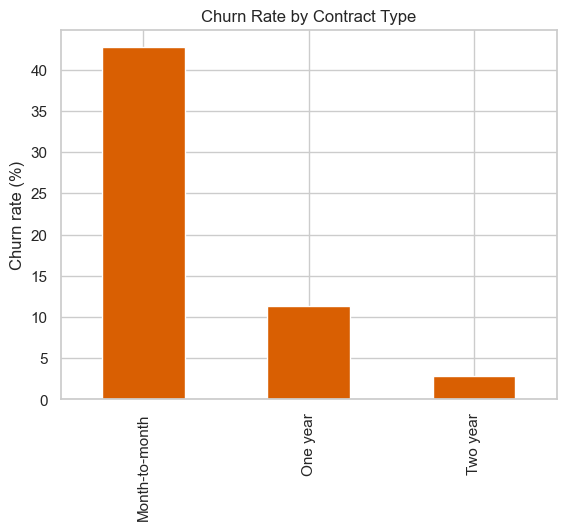

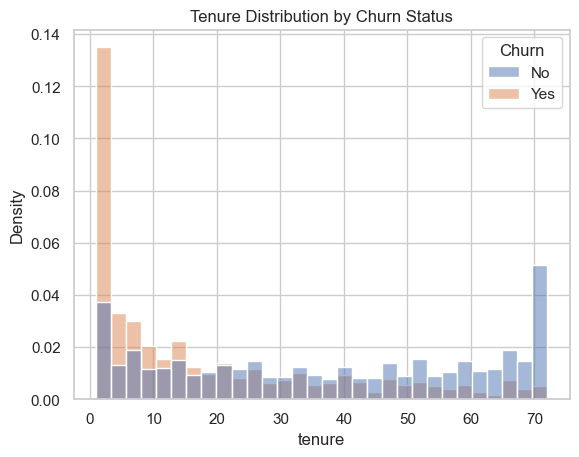

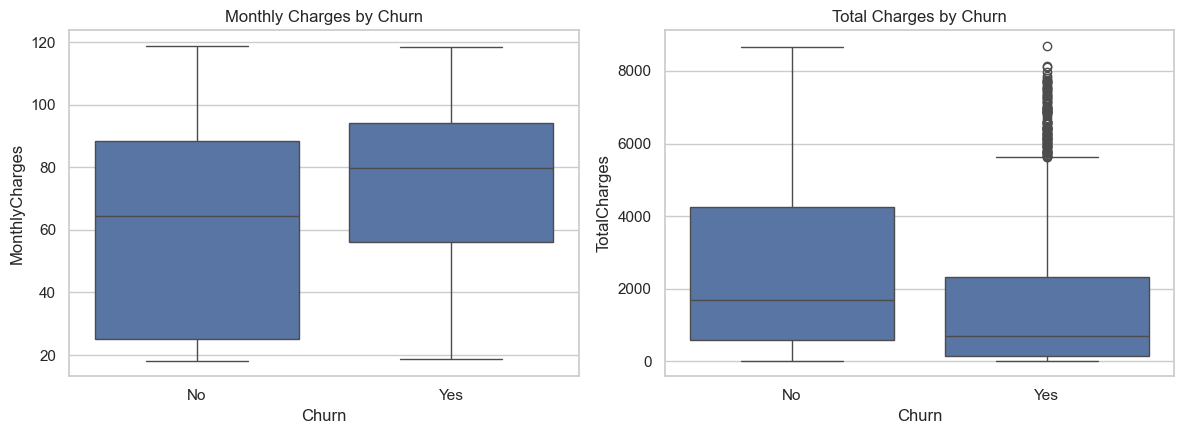

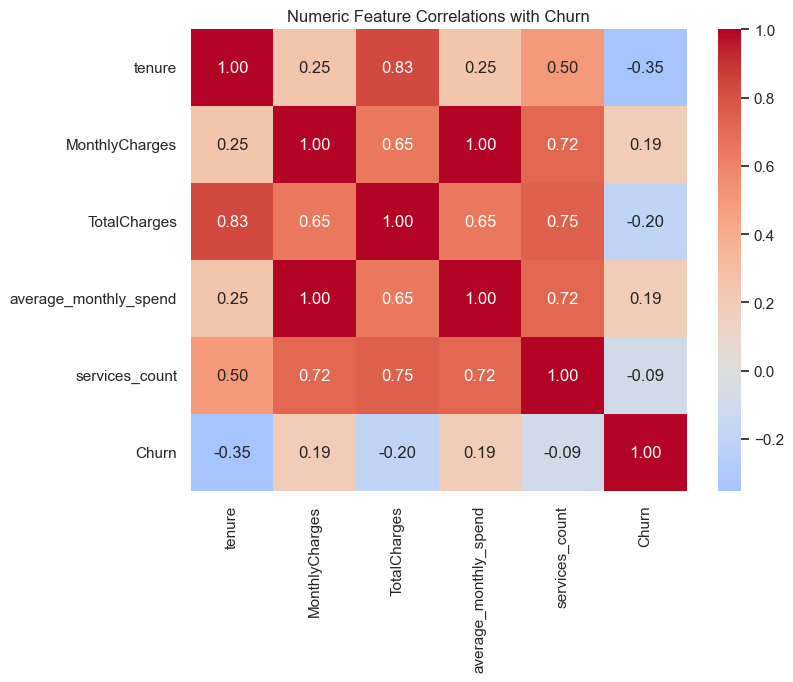

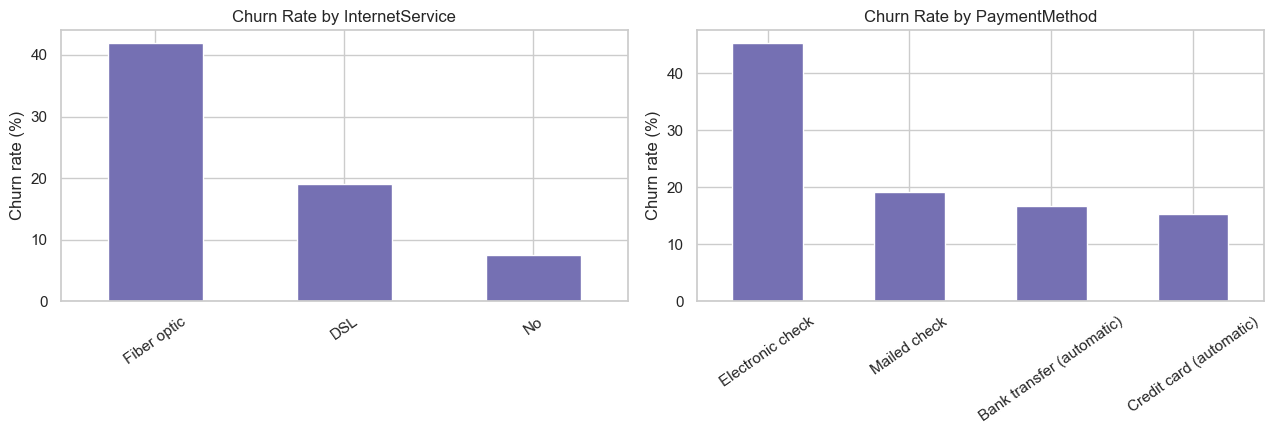

In [4]:
contract_rates = pd.crosstab(df["Contract"], df["Churn"], normalize="index")["Yes"].sort_values(ascending=False)
contract_rates.mul(100).plot(kind="bar", color="#d95f02")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn rate (%)")
plt.xlabel("")
plt.show()

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="layer", stat="density", common_norm=False)
plt.title("Tenure Distribution by Churn Status")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[0])
axes[0].set_title("Monthly Charges by Churn")
sns.boxplot(data=df, x="Churn", y="TotalCharges", ax=axes[1])
axes[1].set_title("Total Charges by Churn")
plt.tight_layout()
plt.show()

numeric_eda = df[["tenure", "MonthlyCharges", "TotalCharges", "average_monthly_spend", "services_count"]].copy()
numeric_eda["Churn"] = df["Churn"].eq("Yes").astype(int)
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_eda.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Numeric Feature Correlations with Churn")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, column in zip(axes, ["InternetService", "PaymentMethod"]):
    rates = pd.crosstab(df[column], df["Churn"], normalize="index")["Yes"].sort_values(ascending=False)
    rates.mul(100).plot(kind="bar", ax=axis, color="#7570b3")
    axis.set_title(f"Churn Rate by {column}")
    axis.set_ylabel("Churn rate (%)")
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 4. Prepare features and create a stratified train-test split

In [5]:
y = df["Churn"].eq("Yes").astype(int)
X = df.drop(columns=["customerID", "Churn"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_columns),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_columns),
])

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")
print(f"Features before encoding: {X.shape[1]}")

Training rows: 5625
Test rows: 1407
Features before encoding: 22


## 5. Train baseline classifiers

In [6]:
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)),
    ]),
    "Random Forest (baseline)": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1)),
    ]),
}

for model in models.values():
    model.fit(X_train, y_train)
print("All baseline models trained.")

All baseline models trained.


## 6. Tune Random Forest with 5-fold GridSearchCV

In [7]:
random_forest_search = GridSearchCV(
    estimator=Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
    ]),
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [8, None],
        "model__min_samples_leaf": [1, 3],
    },
    scoring="f1",
    cv=5,
    n_jobs=1,
    refit=True,
)
random_forest_search.fit(X_train, y_train)
models["Random Forest (tuned)"] = random_forest_search.best_estimator_

print("Best parameters:", random_forest_search.best_params_)
print(f"Best 5-fold cross-validated F1: {random_forest_search.best_score_:.4f}")

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
Best 5-fold cross-validated F1: 0.5774


## 7. Evaluate every model on the same test set

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Decision Tree,0.7818,0.5903,0.5856,0.5879,0.8137
0,Logistic Regression,0.7925,0.6340,0.5187,0.5706,0.8351
3,Random Forest (tuned),0.7903,0.6357,0.4947,0.5564,0.8299
2,Random Forest (baseline),0.7868,0.6267,0.4893,0.5495,0.8187


<Figure size 700x600 with 0 Axes>

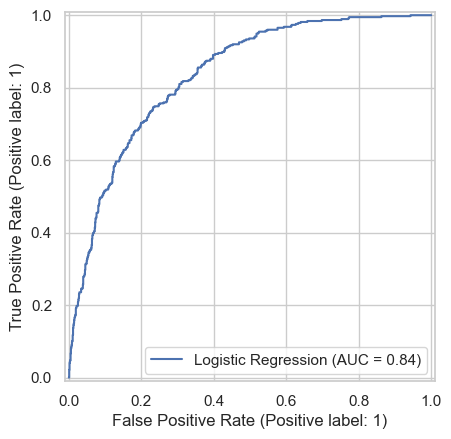

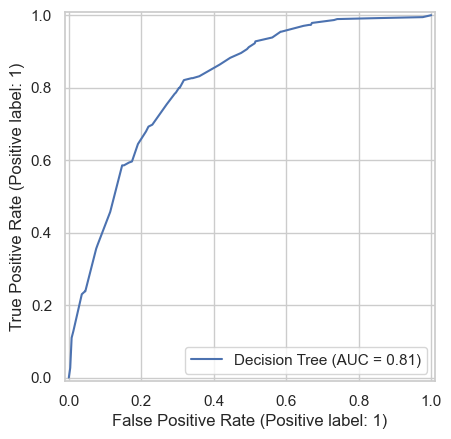

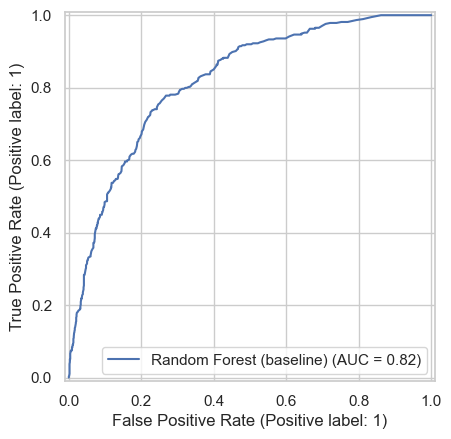

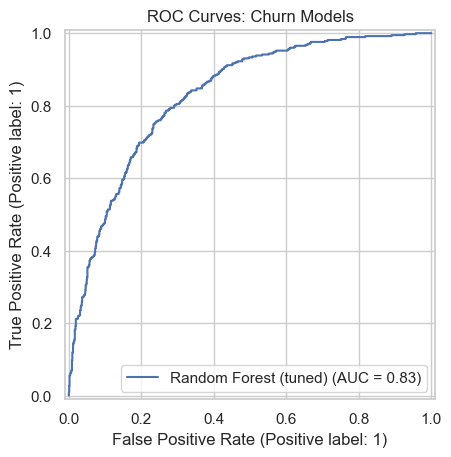

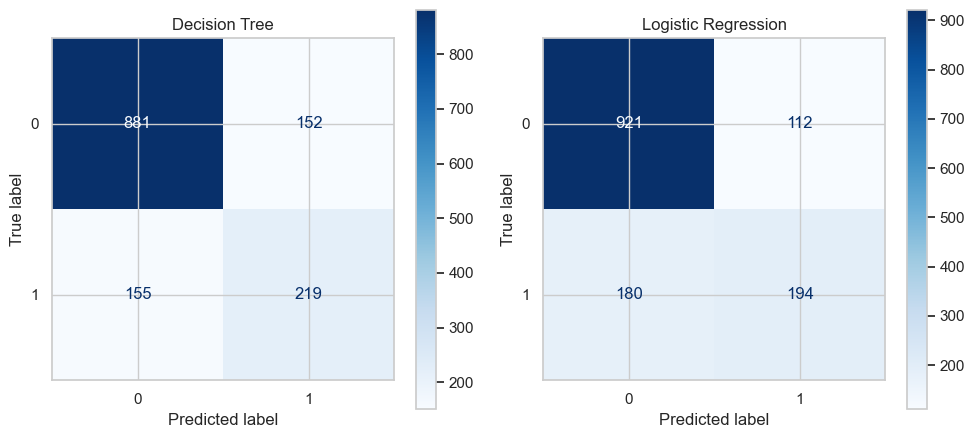

In [8]:
def evaluate_model(name, model):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
    }

comparison = pd.DataFrame(
    [evaluate_model(name, model) for name, model in models.items()]
).sort_values(["F1", "ROC-AUC"], ascending=False)
comparison.to_csv(output_dir / "model_comparison.csv", index=False)
display(comparison.round(4))

plt.figure(figsize=(7, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)
plt.title("ROC Curves: Churn Models")
plt.show()

top_two_models = comparison["Model"].head(2).tolist()
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for axis, name in zip(axes, top_two_models):
    ConfusionMatrixDisplay.from_estimator(models[name], X_test, y_test, ax=axis, cmap="Blues")
    axis.set_title(name)
plt.tight_layout()
plt.show()

## 8. Identify churn drivers and make a deployment recommendation

,Random Forest importance,Logistic coefficient
numeric__tenure,0.119875,-1.286680
numeric__TotalCharges,0.101902,0.320901
numeric__MonthlyCharges,0.095937,-0.245722
numeric__average_monthly_spend,0.095467,0.191755
categorical__Contract_Month-to-month,0.083832,0.689881
categorical__InternetService_Fiber optic,0.043681,0.786004
categorical__tenure_group_0-12,0.042876,-0.087865
categorical__PaymentMethod_Electronic check,0.039834,0.191694
categorical__InternetService_No,0.023061,-0.926078
categorical__Contract_Two year,0.022639,-0.802551


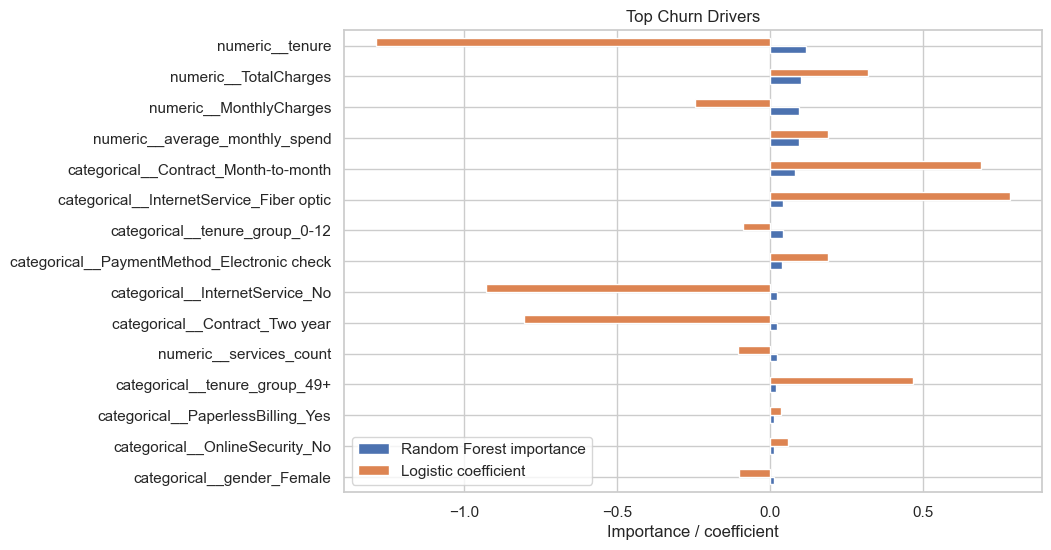

Recommendation: deploy Decision Tree for the initial retention workflow. It has the best test F1 (0.5879) and recall (0.5856), which makes it the strongest choice for identifying customers who are likely to churn.
Retention actions:
1. Prioritize high-risk month-to-month customers for proactive outreach.
2. Offer contract-conversion incentives or bundle discounts to at-risk customers.
3. Promote technical support and online-security bundles where service gaps increase churn risk.


In [9]:
feature_names = models["Random Forest (tuned)"].named_steps["prep"].get_feature_names_out()
feature_drivers = pd.DataFrame({
    "Random Forest importance": models["Random Forest (tuned)"].named_steps["model"].feature_importances_,
    "Logistic coefficient": models["Logistic Regression"].named_steps["model"].coef_[0],
}, index=feature_names).sort_values("Random Forest importance", ascending=False)

display(feature_drivers.head(15))
feature_drivers.head(15).sort_values("Random Forest importance").plot(
    kind="barh", figsize=(9, 6)
)
plt.title("Top Churn Drivers")
plt.xlabel("Importance / coefficient")
plt.show()

best_model = comparison.iloc[0]
print(
    f"Recommendation: deploy {best_model['Model']} for the initial retention workflow. "
    f"It has the best test F1 ({best_model['F1']:.4f}) and recall ({best_model['Recall']:.4f}), "
    "which makes it the strongest choice for identifying customers who are likely to churn."
)
print("Retention actions:")
print("1. Prioritize high-risk month-to-month customers for proactive outreach.")
print("2. Offer contract-conversion incentives or bundle discounts to at-risk customers.")
print("3. Promote technical support and online-security bundles where service gaps increase churn risk.")